# RNN (LSTM) Classifier — Learning Temporal Patterns Directly


## 1. Imports and constants

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, precision_score, recall_score,
)
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Empty list here means training falls back to CPU, which is very slow for this.
# tensorflow-metal registers at import, so a fresh install needs a kernel restart.
gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs visible to TensorFlow: {gpus}")
if not gpus:
    print("No GPU detected — training will run on CPU. If you installed tensorflow-metal "
          "and still see this, restart the kernel (the plugin registers at import time).")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
tf.random.set_seed(42)

RAW_SENSOR_COLS = [
    "SOC", "SOH", "Charging_Cycles", "Battery_Temp", "Motor_RPM", "Motor_Torque",
    "Motor_Temp", "Brake_Pad_Wear", "Charging_Voltage", "Tire_Pressure",
]
TARGETS = ["Fault_Within_6h", "Fault_Within_12h"]
WINDOW_LEN = 24  # hours of raw history per sequence — matches the 24h rolling window used in 01b
RANDOM_STATE = 42

GPUs visible to TensorFlow: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load data + assign a 3-way chronological split (train / val / test)

Making `chronological_split` (last ~20% of each vehicle's
own timeline as test), but the RNN needs a **validation** slice too (for early stopping
— trees don't need this, they don't have epochs).

Split assignment happens on the **row-level dataframe**, before building sequences —
each row gets a `"train"` / `"val"` / `"test"` label. A sequence's split is decided by
its *last* (most recent) row, exactly the row whose `Fault_Within_Nh` value it's
predicting.

In [2]:
def assign_chronological_split(df, group_col="user_profile", time_col="timestamp",
                                test_frac=0.2, val_frac=0.125):
    '''val_frac is applied to the remaining (1 - test_frac) train portion, so the
    overall split is ~70% train / ~10% val / ~20% test.'''
    df = df.copy()
    df["split"] = "train"
    for _, g in df.groupby(group_col):
        g = g.sort_values(time_col)
        n = len(g)
        test_cutoff = int(n * (1 - test_frac))
        val_cutoff = int(test_cutoff * (1 - val_frac))
        df.loc[g.index[val_cutoff:test_cutoff], "split"] = "val"
        df.loc[g.index[test_cutoff:], "split"] = "test"
    return df


df_full = pd.read_csv(
    "../data/processed/driving_pattern_diagnostics_sequence_features.csv",
    parse_dates=["timestamp"],
)
df_full = df_full.sort_values(["user_profile", "timestamp"]).reset_index(drop=True)
df_full = assign_chronological_split(df_full)

print(df_full.groupby("split")["timestamp"].agg(["min", "max", "count"]).loc[["train", "val", "test"]])

                      min                 max   count
split                                                
train 2020-01-01 23:00:00 2023-07-01 17:00:00  122572
val   2023-07-01 18:00:00 2023-12-31 03:00:00   17512
test  2023-12-31 04:00:00 2024-12-29 23:00:00   35024


## 3. Build sliding-window sequences
One sequence per row: the trailing 24 hours of raw sensor values, ending on that row. Same

The first 23 rows of each vehicle don't have enough history behind them and get dropped.

Windows only look backwards, so a training window can't reach into test rows. Reaching
back into earlier training rows is just past data.

In [3]:
def make_sequences(df, feature_cols, target_col, window_len,
                    group_col="user_profile", time_col="timestamp", split_col="split"):
    d = df.dropna(subset=[target_col]).sort_values([group_col, time_col])
    X_chunks, y_chunks, split_chunks = [], [], []
    for _, g in d.groupby(group_col):
        g = g.sort_values(time_col)
        feats = g[feature_cols].to_numpy(dtype="float32")
        targets = g[target_col].to_numpy()
        splits = g[split_col].to_numpy()
        n = len(g)
        if n < window_len:
            continue
        # Sliding windows via as_strided-free approach (clear over clever, this is a one-time build step).
        for i in range(window_len - 1, n):
            X_chunks.append(feats[i - window_len + 1 : i + 1])
            y_chunks.append(targets[i])
            split_chunks.append(splits[i])
    X = np.stack(X_chunks)
    y = np.array(y_chunks, dtype=bool)
    split = np.array(split_chunks)
    return X, y, split


def build_train_val_test(df_full, target, feature_cols=RAW_SENSOR_COLS, window_len=WINDOW_LEN):
    X, y, split = make_sequences(df_full, feature_cols, target, window_len)

    X_train, y_train = X[split == "train"], y[split == "train"]
    X_val, y_val = X[split == "val"], y[split == "val"]
    X_test, y_test = X[split == "test"], y[split == "test"]

    # Fit scaler on train fold only, flattened to 2D, then reshape back to 3D.
    n_features = X_train.shape[-1]
    scaler = StandardScaler().fit(X_train.reshape(-1, n_features))

    def scale(arr):
        shape = arr.shape
        return scaler.transform(arr.reshape(-1, n_features)).reshape(shape).astype("float32")

    return {
        "X_train": scale(X_train), "y_train": y_train,
        "X_val": scale(X_val), "y_val": y_val,
        "X_test": scale(X_test), "y_test": y_test,
        "scaler": scaler,
    }


sequence_data = {target: build_train_val_test(df_full, target) for target in TARGETS}

for target, d in sequence_data.items():
    print(f"{target}: train {d['X_train'].shape}, val {d['X_val'].shape}, test {d['X_test'].shape}")
    print(f"  positive rate — train {d['y_train'].mean()*100:.2f}%, "
          f"val {d['y_val'].mean()*100:.2f}%, test {d['y_test'].mean()*100:.2f}%")

Fault_Within_6h: train (122480, 24, 10), val (17512, 24, 10), test (35000, 24, 10)
  positive rate — train 8.87%, val 9.71%, test 9.40%
Fault_Within_12h: train (122480, 24, 10), val (17512, 24, 10), test (34976, 24, 10)
  positive rate — train 16.80%, val 18.38%, test 17.82%


## 4. Model architecture

Two LSTM layers, both small. With 9-17% positive rate and only 10 features there isn't
much signal to find, and a bigger network would overfit the majority class before it found
anything the tree ensembles missed. Worth growing only if train and validation loss both
plateau high.

Dropout after each recurrent layer for the same reason.

In [4]:
def build_rnn(window_len, n_features):
    model = keras.Sequential([
        layers.Input(shape=(window_len, n_features)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), keras.metrics.Recall(name="recall")],
    )
    return model


build_rnn(WINDOW_LEN, len(RAW_SENSOR_COLS)).summary()

2026-08-03 23:05:16.280822: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-08-03 23:05:16.281045: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-08-03 23:05:16.281057: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-08-03 23:05:16.281325: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-03 23:05:16.281340: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,161 (125.63 KB)

 Trainable params: 32,161 (125.63 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train

`class_weight` is the Keras equivalent of `class_weight="balanced"`, computed from the
training fold only.

Early stopping watches validation AUC rather than training loss, and
`restore_best_weights` rolls back to the best epoch instead of keeping whatever the last
one produced.

In [5]:
def train_rnn(data, window_len=WINDOW_LEN, n_features=len(RAW_SENSOR_COLS), epochs=30, batch_size=256):
    model = build_rnn(window_len, n_features)

    pos_rate = data["y_train"].mean()
    class_weight = {0: 0.5 / (1 - pos_rate), 1: 0.5 / pos_rate}

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=5, restore_best_weights=True,
    )

    history = model.fit(
        data["X_train"], data["y_train"].astype("float32"),
        validation_data=(data["X_val"], data["y_val"].astype("float32")),
        epochs=epochs, batch_size=batch_size, class_weight=class_weight,
        callbacks=[early_stop], verbose=2,
    )
    return model, history

rnn_models, rnn_histories = {}, {}
for target in TARGETS:
    print(f"\n{'='*70}\nTraining RNN for {target}\n{'='*70}")
    model, history = train_rnn(sequence_data[target])
    rnn_models[target] = model
    rnn_histories[target] = history


Training RNN for Fault_Within_6h
Epoch 1/30


2026-08-03 23:05:17.916065: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


479/479 - 21s - 44ms/step - auc: 0.7433 - loss: 0.5885 - recall: 0.7706 - val_auc: 0.7625 - val_loss: 0.5870 - val_recall: 0.8347
Epoch 2/30
479/479 - 11s - 24ms/step - auc: 0.7751 - loss: 0.5499 - recall: 0.8454 - val_auc: 0.7636 - val_loss: 0.5852 - val_recall: 0.8694
Epoch 3/30
479/479 - 11s - 23ms/step - auc: 0.7793 - loss: 0.5433 - recall: 0.8598 - val_auc: 0.7604 - val_loss: 0.5923 - val_recall: 0.8835
Epoch 4/30
479/479 - 12s - 24ms/step - auc: 0.7832 - loss: 0.5380 - recall: 0.8625 - val_auc: 0.7585 - val_loss: 0.5962 - val_recall: 0.8653
Epoch 5/30
479/479 - 12s - 24ms/step - auc: 0.7859 - loss: 0.5355 - recall: 0.8567 - val_auc: 0.7625 - val_loss: 0.5716 - val_recall: 0.8453
Epoch 6/30
479/479 - 11s - 24ms/step - auc: 0.7888 - loss: 0.5325 - recall: 0.8629 - val_auc: 0.7597 - val_loss: 0.5773 - val_recall: 0.8382
Epoch 7/30
479/479 - 12s - 26ms/step - auc: 0.7933 - loss: 0.5276 - recall: 0.8585 - val_auc: 0.7591 - val_loss: 0.5750 - val_recall: 0.8429

Training RNN for Fault_

## 6. Training curves

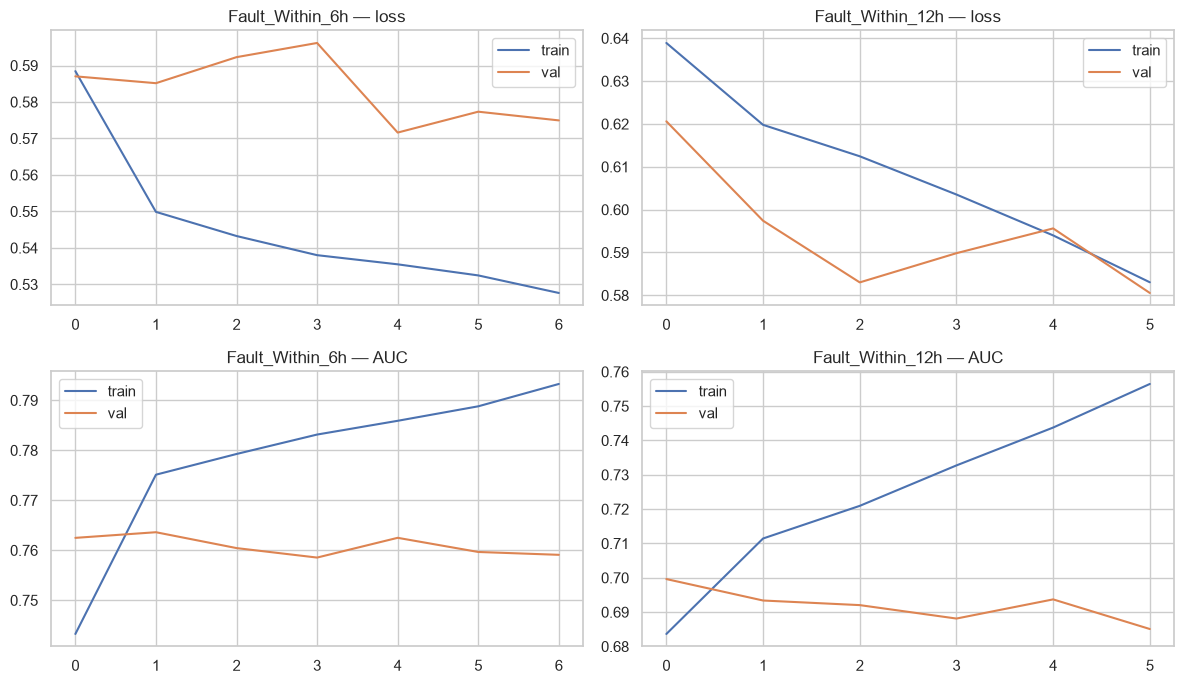

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for col, target in enumerate(TARGETS):
    hist = rnn_histories[target].history
    axes[0, col].plot(hist["loss"], label="train")
    axes[0, col].plot(hist["val_loss"], label="val")
    axes[0, col].set_title(f"{target} — loss")
    axes[0, col].legend()

    axes[1, col].plot(hist["auc"], label="train")
    axes[1, col].plot(hist["val_auc"], label="val")
    axes[1, col].set_title(f"{target} — AUC")
    axes[1, col].legend()
plt.tight_layout()
plt.show()

## 7. Evaluate on the held-out test sequences

Metrics : macro F1, recall/precision on the positive class, confusion matrix — never raw accuracy. 
The classification threshold defaults to 0.5.

In [7]:
rnn_results = []
rnn_preds = {}
for target in TARGETS:
    d = sequence_data[target]
    proba = rnn_models[target].predict(d["X_test"], verbose=0).ravel()
    pred = proba >= 0.5
    rnn_preds[target] = {"proba": proba, "pred": pred}

    rnn_results.append({
        "target": target,
        "macro_F1": f1_score(d["y_test"], pred, average="macro"),
        "recall_positive": recall_score(d["y_test"], pred, pos_label=True),
        "precision_positive": precision_score(d["y_test"], pred, pos_label=True),
    })

    print(f"=== {target} — RNN (threshold 0.5) ===")
    print(classification_report(d["y_test"], pred, labels=[False, True],
                                 target_names=["No fault", "Fault"], digits=3))

pd.DataFrame(rnn_results).set_index("target")

=== Fault_Within_6h — RNN (threshold 0.5) ===
              precision    recall  f1-score   support

    No fault      0.975     0.528     0.685     31710
       Fault      0.160     0.868     0.271      3290

    accuracy                          0.560     35000
   macro avg      0.568     0.698     0.478     35000
weighted avg      0.898     0.560     0.646     35000

=== Fault_Within_12h — RNN (threshold 0.5) ===
              precision    recall  f1-score   support

    No fault      0.891     0.638     0.744     28744
       Fault      0.277     0.639     0.386      6232

    accuracy                          0.638     34976
   macro avg      0.584     0.639     0.565     34976
weighted avg      0.781     0.638     0.680     34976



,macro_F1,recall_positive,precision_positive
target,,,
Fault_Within_6h,0.477815,0.868085,0.160269
Fault_Within_12h,0.565002,0.639442,0.276928


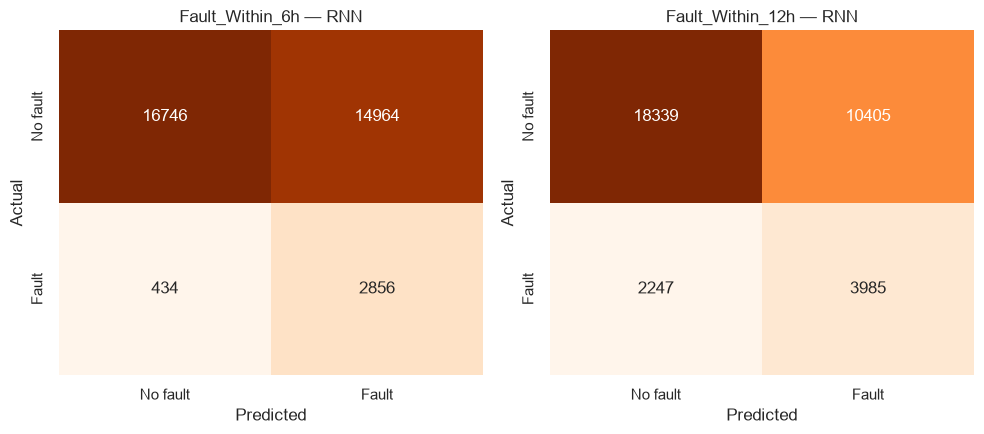

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, target in zip(axes, TARGETS):
    cm = confusion_matrix(sequence_data[target]["y_test"], rnn_preds[target]["pred"], labels=[False, True])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", cbar=False,
                xticklabels=["No fault", "Fault"], yticklabels=["No fault", "Fault"], ax=ax)
    ax.set_title(f"{target} — RNN")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 8. Is 0.5 actually the right threshold?

`class_weight` keeps the model from defaulting to the majority class during training, but 0.5 on the sigmoid output is still an arbitrary cutoff rather than a derived one. Sweeping it on validation, with test left alone, is the defensible version.

In [9]:
def best_threshold(model, X_val, y_val, metric=f1_score, **metric_kwargs):
    val_proba = model.predict(X_val, verbose=0).ravel()
    thresholds = np.linspace(0.05, 0.95, 37)
    scores = [metric(y_val, val_proba >= t, **metric_kwargs) for t in thresholds]
    best_t = thresholds[int(np.argmax(scores))]
    return best_t, dict(zip(thresholds.round(2), np.round(scores, 4)))


tuned_results = []
for target in TARGETS:
    d = sequence_data[target]
    best_t, _ = best_threshold(rnn_models[target], d["X_val"], d["y_val"], average="macro")
    tuned_pred = rnn_preds[target]["proba"] >= best_t

    tuned_results.append({
        "target": target,
        "best_threshold": best_t,
        "macro_F1_tuned": f1_score(d["y_test"], tuned_pred, average="macro"),
        "macro_F1_default_0.5": f1_score(d["y_test"], rnn_preds[target]["pred"], average="macro"),
        "recall_positive_tuned": recall_score(d["y_test"], tuned_pred, pos_label=True),
        "precision_positive_tuned": precision_score(d["y_test"], tuned_pred, pos_label=True),
    })

pd.DataFrame(tuned_results).set_index("target").round(3)

,best_threshold,macro_F1_tuned,macro_F1_default_0.5,recall_positive_tuned,precision_positive_tuned
target,,,,,
Fault_Within_6h,0.65,0.609,0.478,0.429,0.252
Fault_Within_12h,0.60,0.615,0.565,0.425,0.347


## 9. Head-to-head: RNN vs. the ensemble, same test rows

In [10]:
SEQ_SENSORS = ["Motor_RPM", "Motor_Torque", "Motor_Temp", "Battery_Temp"]
SEQ_FEATURE_COLS = [
    f"{s}_{stat}" for s in SEQ_SENSORS
    for stat in (
        [f"roll_mean_{w}h" for w in (6, 12, 24)] + [f"roll_std_{w}h" for w in (6, 12, 24)]
        + [f"lag_{l}h" for l in (1, 3, 6)] + ["delta_6h"]
    )
]
TABULAR_FEATURE_COLS = RAW_SENSOR_COLS + SEQ_FEATURE_COLS

comparison_rows = []
for target in TARGETS:
    horizon = target.replace("Fault_Within_", "").lower()

    # Rebuild the exact same row-level test set the sequences came from (same split rule).
    test_rows = df_full[(df_full["split"] == "test") & df_full[target].notna()].copy()
    test_rows[target] = test_rows[target].astype(bool)
    # Drop the first WINDOW_LEN-1 test rows per vehicle so both approaches score the identical rows.
    test_rows = test_rows.sort_values(["user_profile", "timestamp"])
    test_rows["row_in_test"] = test_rows.groupby("user_profile").cumcount()
    test_rows = test_rows[test_rows["row_in_test"] >= WINDOW_LEN - 1]

    X_tab_test = test_rows[TABULAR_FEATURE_COLS]
    y_tab_test = test_rows[target]

    row = {"target": target, "RNN (tuned threshold)": tuned_results[TARGETS.index(target)]["macro_F1_tuned"]}
    for slug, name in [("random_forest", "Random Forest"), ("xgboost", "XGBoost"),
                        ("lightgbm", "LightGBM"), ("ensemble", "Ensemble (soft voting)")]:
        path = f"../models/ensemble_{horizon}_{slug}.joblib"
        if not os.path.exists(path):
            row[name] = None
            continue
        tab_model = joblib.load(path)
        tab_pred = tab_model.predict(X_tab_test)
        row[name] = f1_score(y_tab_test, tab_pred, average="macro")
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index("target")
comparison_df.round(4)

,RNN (tuned threshold),Random Forest,XGBoost,LightGBM,Ensemble (soft voting)
target,,,,,
Fault_Within_6h,0.6091,0.5981,0.5855,0.5914,0.5994
Fault_Within_12h,0.6148,0.6103,0.5962,0.6019,0.6082


## 10. Save models

In [11]:
os.makedirs("../models", exist_ok=True)
for target in TARGETS:
    horizon = target.replace("Fault_Within_", "").lower()
    rnn_models[target].save(f"../models/rnn_{horizon}.keras")
    joblib.dump(sequence_data[target]["scaler"], f"../models/rnn_{horizon}_scaler.joblib")
    print(f"Saved RNN + scaler for {target} to ../models/rnn_{horizon}.keras / _scaler.joblib")

Saved RNN + scaler for Fault_Within_6h to ../models/rnn_6h.keras / _scaler.joblib
Saved RNN + scaler for Fault_Within_12h to ../models/rnn_12h.keras / _scaler.joblib
